In [1]:
import matplotlib.pyplot as plt
import ODESolve_slow as ODE
import numpy as np
import derivatives as der
import nseabundance as nse
import weakrates as weak
from constants import hbar
import scipy

In [2]:
def a_total_y_tot(eta_final, Q0, a0, np_factor, pn_factor, rhonu):
    p = np.array([0, Q0, a0, np_factor, pn_factor, rhonu])
    
    T0 = 15
    a0 = 1/T0
    t0 = 0
    eta0 = eta_final*(11/4)
    Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
    Yn0 = 1-Yp0

    y0 = der.depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
    dx0=0.001

    N_step = 1000
    dN = 20

    x_final = 0.4

    a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
    print(done)

    a1 = a[-1]
    T1 = y[-1, 0]
    t1 = y[-1, 1]
    eta1 = y[-1, 2]
    Y1 = der.depvar(T1,t1,eta1,nse.nse(T1,eta1,y[-1,3], y[-1,4]))
    dx1 = dx[-1]*0.001
    p[0] = 2
    Nstep = 1000
    dN = 50
    x_final = 1000

    a2, y2, dx2, done = ODE.ODEOneRun(a1, Y1, dx1, p, Nstep, dN, x_final)
    print(done)
    for i in range(len(a)):
        A_nse = nse.nse(y[i,0], y[i,2], y[i,3],y[i,4])
        y[i,3:] = A_nse   

    a_total = np.concatenate((a[:-1],a2))   #creates an array of all the ind var values
    #len(a_total) = len(a)-1+len(a2)
    y_total = np.concatenate((y[:-1,:],y2),axis = 0) #creates a matrix of dep var values
    #y_total.shape is len(a_total) x 12

    return a_total, y_total

In [3]:
a_total, y_total = a_total_y_tot(6.1e-10, 0, 1, 1, 1, 0)
np.savez("standard", a = a_total, y = y_total)

a_total, y_total = a_total_y_tot(9e-10, 0, 1, 1, 1, 0)
np.savez("high_eta", a = a_total, y = y_total)

a_total, y_total = a_total_y_tot(3e-10, 0, 1, 1, 1, 0)
np.savez("low_eta", a = a_total, y = y_total)

True
True
True
True
True
True


In [4]:
eta_CMB = 6.1e-10
def intro_heat(Q0, a0=1):
    a_tot, y_tot = a_total_y_tot(eta_CMB, Q0, a0, 1, 1, 0)

    if (np.abs(1 - y_tot[-1,2] / eta_CMB) < 0.01):
        return a_tot, y_tot

    a_total, y_total = a_total_y_tot(eta_CMB * eta_CMB / y_tot[-1,2], Q0, a0, 1, 1, 0)

    return a_total, y_total

In [5]:
a_total, y_total = intro_heat(0.3, 1)
np.savez("Q3", a = a_total, y = y_total)

a_total, y_total = intro_heat(0.006, 6)
np.savez("Q6", a = a_total, y = y_total)


True
True
True
True
True
True
True
True


In [6]:
data = np.load("standard.npz")
a_total = data['a']
y_total = data['y']

data = np.load("high_eta.npz")
a_total_high = data['a']
y_total_high = data['y']

data = np.load("low_eta.npz")
a_total_low = data['a']
y_total_low = data['y']

data = np.load("Q3.npz")
a_total_Q3 = data['a']
y_total_Q3 = data['y']

data = np.load("Q6.npz")
a_total_Q6 = data['a']
y_total_Q6 = data['y']

timeTemp = scipy.interpolate.interp1d(y_total[:,1]*hbar, y_total[:,0], kind='cubic')
def time_to_temp(t):
    return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)

tempTime = scipy.interpolate.interp1d(y_total[:,0],y_total[:,1]*hbar,  kind='cubic')
def temp_to_time(T):
    return y_total[-1,1]*hbar * (T / y_total[-1,0])**(-2)

In [7]:
nseval=np.zeros((9,len(a_total)))
    
for i in range(len(a_total)):
    nseval[:,i] = nse.nse(y_total[i,0] , y_total[i,2] , y_total[i,3] , y_total[i,4],)

/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_13365/2056403708.py:23: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


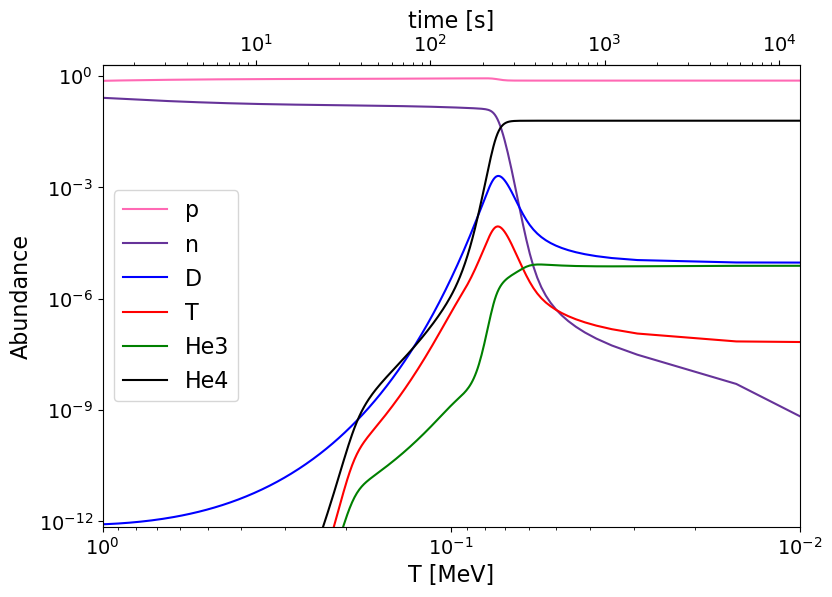

In [8]:

fig, ax = plt.subplots(figsize=(9,6))
ax.loglog(y_total[:,0], y_total[:,3+nse.P_INDEX], color="hotpink", label="p")
ax.loglog(y_total[:,0], y_total[:,3+nse.N_INDEX], color="rebeccapurple", label="n")
ax.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX], color="blue", label="D")
ax.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], color="red", label="T")
ax.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], color="green", label="He3")
ax.loglog(y_total[:,0], y_total[:,3+nse.HE4_INDEX], color="black", label="He4")
ax.legend(loc='center left', fontsize=16)

ax.set_xlabel("T [MeV]", fontsize=16)
ax.set_ylabel("Abundance", fontsize=16)
ax.set_ylim(0.7e-12, 2)
ax.set_xlim(1, 0.01)
plt.xticks(fontsize=14)
plt.yticks([1e-12, 1e-9, 1e-6, 1e-3, 1],fontsize=14)

timeax = ax.secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=16)
timeax.tick_params(axis='x', labelsize=14)

plt.savefig("BBN.png", bbox_inches="tight")

/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_13365/2056403708.py:23: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


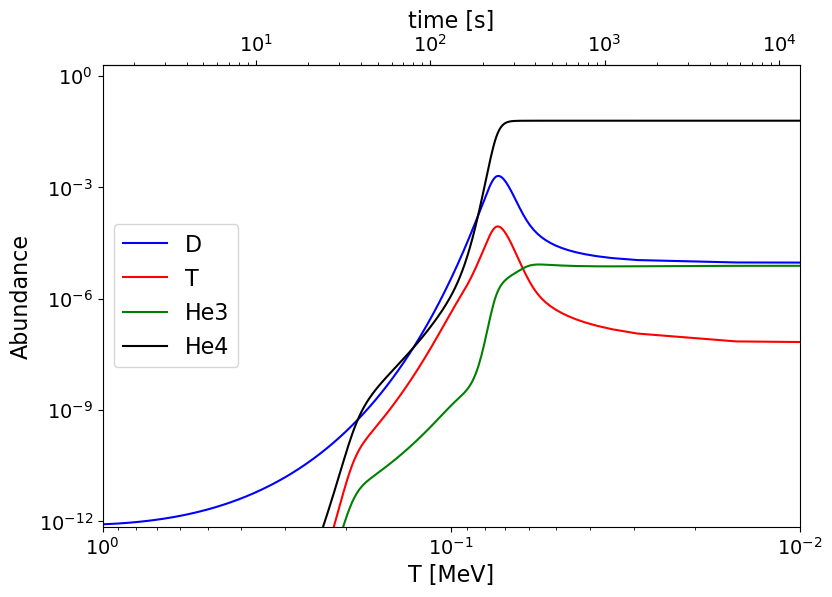

In [12]:
fig, ax = plt.subplots(figsize=(9,6))
#ax.loglog(y_total[:,0], y_total[:,3+nse.P_INDEX], color="lightgray", label="p")
#ax.loglog(y_total[:,0], y_total[:,3+nse.N_INDEX], color="rebeccapurple", label="n")
ax.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX], color="blue", label="D")
ax.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], color="red", label="T")
ax.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], color="green", label="He3")
ax.loglog(y_total[:,0], y_total[:,3+nse.HE4_INDEX], color="black", label="He4")
ax.legend(loc='center left', fontsize=16)

ax.set_xlabel("T [MeV]", fontsize=16)
ax.set_ylabel("Abundance", fontsize=16)
ax.set_ylim(0.7e-12, 2)
ax.set_xlim(1, 0.01)
plt.xticks(fontsize=14)
plt.yticks([1e-12, 1e-9, 1e-6, 1e-3, 1],fontsize=14)

timeax = ax.secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=16)
timeax.tick_params(axis='x', labelsize=14)

/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_13365/2056403708.py:23: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


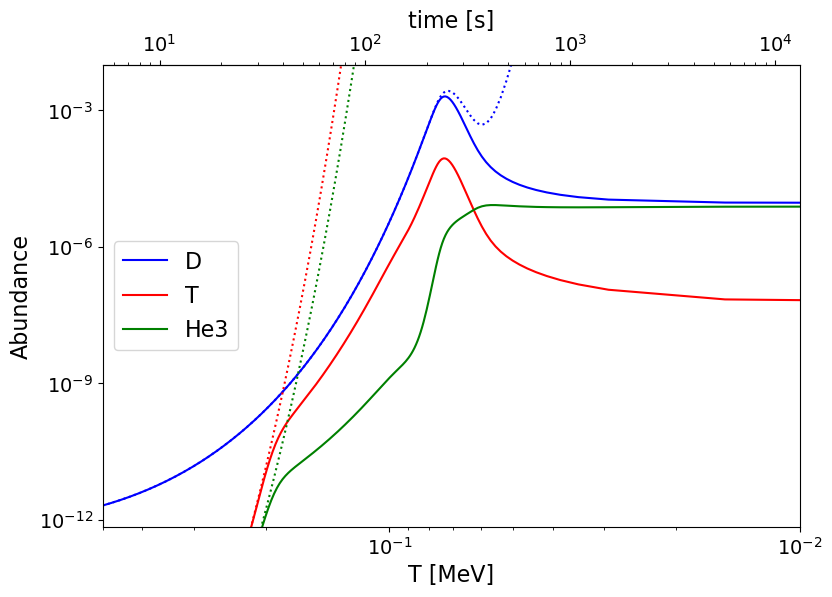

In [13]:
plot_index = np.where(y_total[:,0] > 0.04)[0]

fig, ax = plt.subplots(figsize=(9,6))
ax.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX], color="blue", label="D")
ax.loglog(y_total[plot_index,0], nseval[nse.H2_INDEX,plot_index], color="blue", ls=":")

ax.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX], color="red", label="T")
ax.loglog(y_total[plot_index,0], nseval[nse.H3_INDEX,plot_index], color="red", ls=":")

ax.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX], color="green", label="He3")
ax.loglog(y_total[plot_index,0], nseval[nse.HE3_INDEX,plot_index], color="green", ls=":")

ax.legend(loc='center left', fontsize=16)
ax.set_ylim(0.7e-12, 1e-2)
ax.set_xlim(0.5, 0.01)
plt.xticks(fontsize=14)
plt.yticks([1e-12, 1e-9, 1e-6, 1e-3],fontsize=14)
plt.xlabel("T [MeV]", fontsize=16)
plt.ylabel("Abundance", fontsize=16)
timeax = ax.secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=16)
timeax.tick_params(axis='x', labelsize=14)

plt.savefig("NSE.png", bbox_inches="tight")


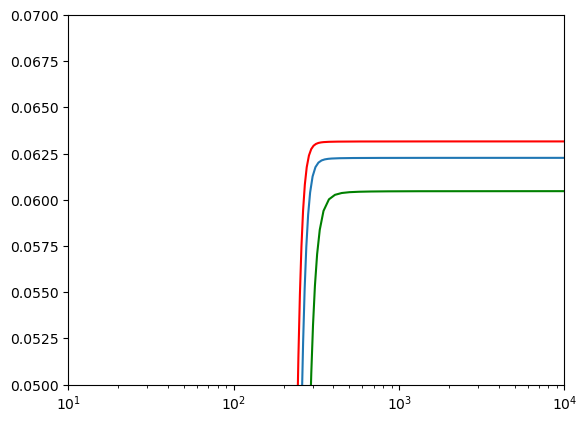

In [15]:
plt.figure()
plt.loglog(y_total_low[:,1] * hbar, y_total_low[:,3+nse.HE4_INDEX], color = "green")
plt.loglog(y_total[:,1] * hbar, y_total[:,3+nse.HE4_INDEX],)
plt.loglog(y_total_high[:,1] * hbar, y_total_high[:,3+nse.HE4_INDEX], color = "red")
plt.xlim(10, 1e4)
plt.ylim(0.05, 0.07)
plt.yscale("linear")

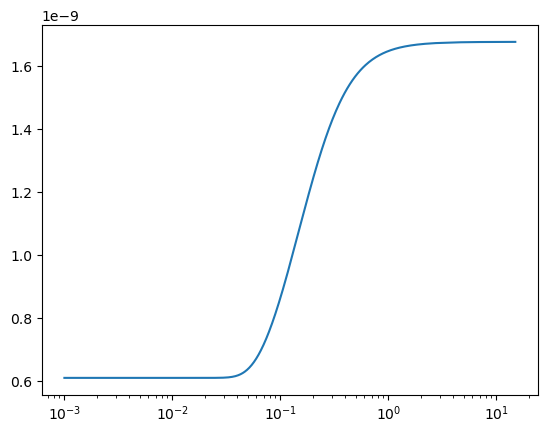

In [16]:
plt.semilogx(1/a_total, y_total[:,2])

(1e-12, 1)

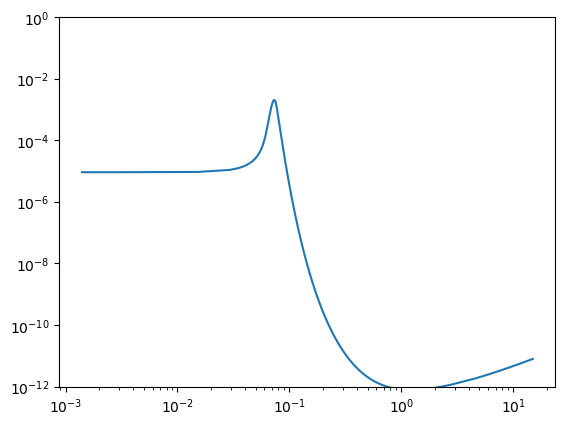

In [17]:
plt.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX])
plt.ylim(1e-12, 1)

(1e-12, 1)

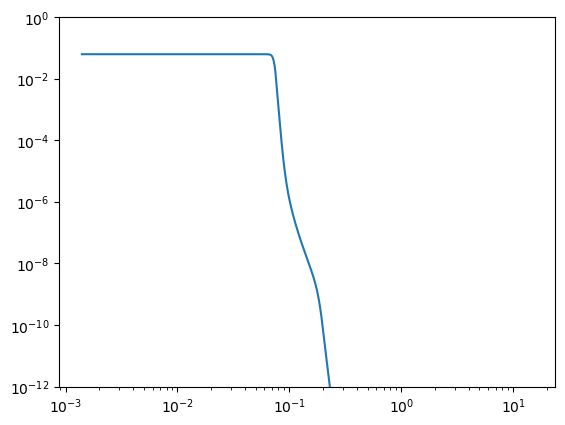

In [18]:
plt.loglog(y_total[:,0], y_total[:,3+nse.HE4_INDEX])
plt.ylim(1e-12, 1)

(1e-12, 1)

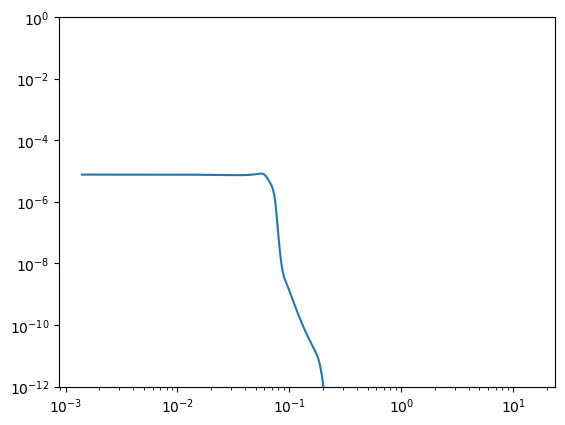

In [19]:
plt.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX])
plt.ylim(1e-12, 1)

(15, 0.01)

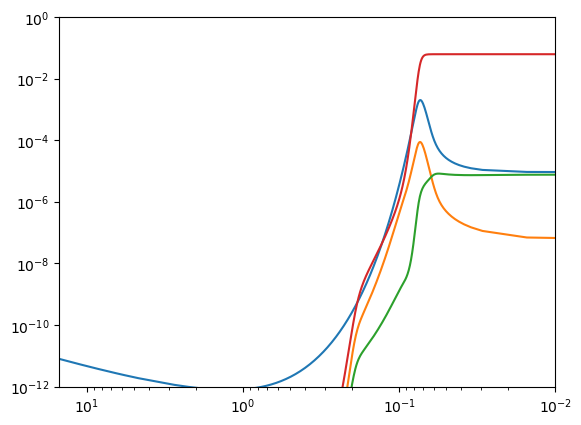

In [20]:
plt.loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX])
plt.loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX])
plt.loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX])
plt.loglog(y_total[:,0], y_total[:,3+nse.HE4_INDEX])
plt.ylim(1e-12, 1)
plt.xlim(15, 0.01)

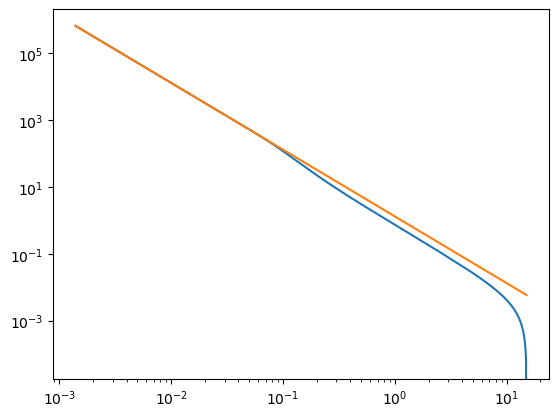

In [21]:
plt.loglog(y_total[:,0], y_total[:,1]*hbar)
plt.loglog(y_total[:,0], y_total[-1,1]*hbar * (y_total[:,0] / y_total[-1,0])**(-2))


/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_13365/3963087428.py:2: RuntimeWarning: divide by zero encountered in power
  plt.loglog(y_total[:,1]*hbar, y_total[-1,0] * (y_total[:,1] / y_total[-1,1])**(-0.5))


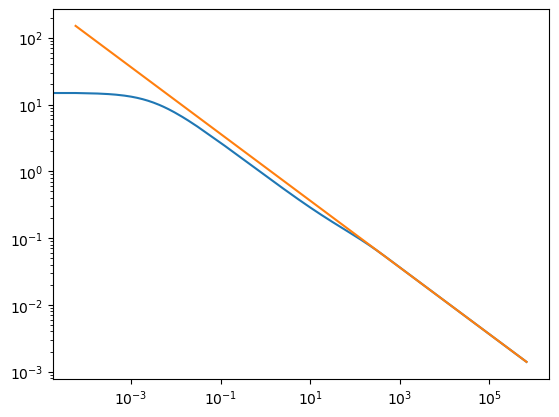

In [22]:
plt.loglog(y_total[:,1]*hbar, y_total[:,0])
plt.loglog(y_total[:,1]*hbar, y_total[-1,0] * (y_total[:,1] / y_total[-1,1])**(-0.5))


/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_13365/2056403708.py:23: RuntimeWarning: divide by zero encountered in power
  return y_total[-1,0] * (t / y_total[-1,1]/hbar)**(-0.5)


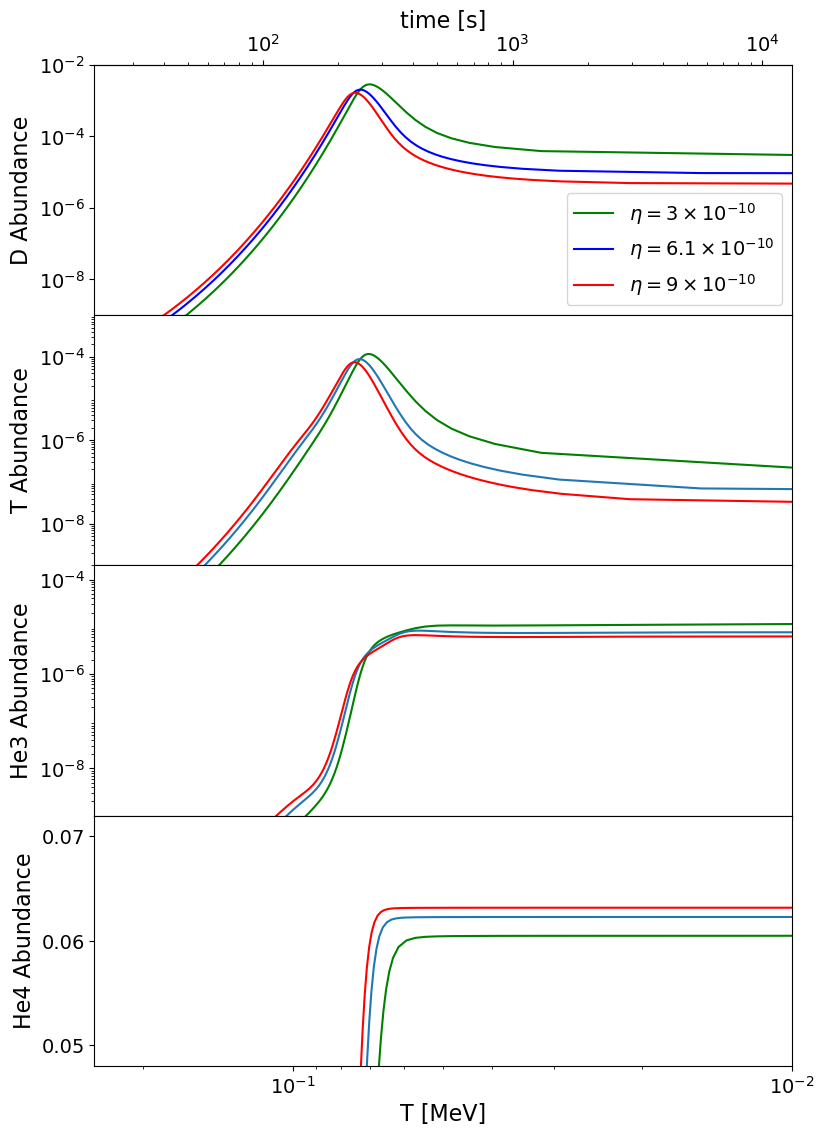

In [23]:
fig, ax = plt.subplots(4, 1, figsize=(9,13), sharex='col')
fig.subplots_adjust(hspace=0)

ax[0].loglog(y_total_low[:,0], y_total_low[:,3+nse.H2_INDEX], color = "green", label=r"$\eta = 3 \times 10^{-10}$")
ax[0].loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX],color = "blue", label=r"$\eta = 6.1 \times 10^{-10}$")
ax[0].loglog(y_total_high[:,0], y_total_high[:,3+nse.H2_INDEX], color = "red", label=r"$\eta = 9 \times 10^{-10}$")
ax[0].set_xlim(0.25, 0.01)
ax[0].set_ylabel("D Abundance", fontsize=16)
ax[0].set_yticks([1e-8, 1e-6, 1e-4, 1e-2])
ax[0].tick_params(axis='y', labelsize=14)
ax[0].set_ylim(1e-9,1e-2)
ax[0].legend(loc = "lower right", fontsize=14)

timeax = ax[0].secondary_xaxis('top', functions=(temp_to_time, time_to_temp))
timeax.set_xlabel("time [s]", fontsize=16)
timeax.tick_params(axis='x', labelsize=14)

ax[1].loglog(y_total_low[:,0], y_total_low[:,3+nse.H3_INDEX], color = "green")
ax[1].loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX],)
ax[1].loglog(y_total_high[:,0], y_total_high[:,3+nse.H3_INDEX], color = "red")
ax[1].set_ylabel("T Abundance", fontsize=16)
ax[1].set_yticks([1e-8, 1e-6, 1e-4])
ax[1].set_ylim(1e-9,1e-3)
ax[1].tick_params(axis='y', labelsize=14)

ax[2].loglog(y_total_low[:,0], y_total_low[:,3+nse.HE3_INDEX], color = "green")
ax[2].loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX],)
ax[2].loglog(y_total_high[:,0], y_total_high[:,3+nse.HE3_INDEX], color = "red")
ax[2].set_ylabel("He3 Abundance", fontsize=16)
ax[2].set_yticks([1e-8, 1e-6, 1e-4])
ax[2].set_ylim(1e-9,2e-4)
ax[2].tick_params(axis='y', labelsize=14)

ax[3].semilogx(y_total_low[:,0], y_total_low[:,3+nse.HE4_INDEX], color = "green")
ax[3].semilogx(y_total[:,0], y_total[:,3+nse.HE4_INDEX],)
ax[3].semilogx(y_total_high[:,0], y_total_high[:,3+nse.HE4_INDEX], color = "red")
ax[3].set_ylabel("He4 Abundance", fontsize=16)
ax[3].set_yticks([0.05, 0.06, 0.07])
ax[3].set_ylim(0.048, 0.072)
ax[3].tick_params(axis='both', labelsize=14)
ax[3].set_xlabel("T [MeV]", fontsize=16)

plt.savefig("eta.png", bbox_inches="tight")

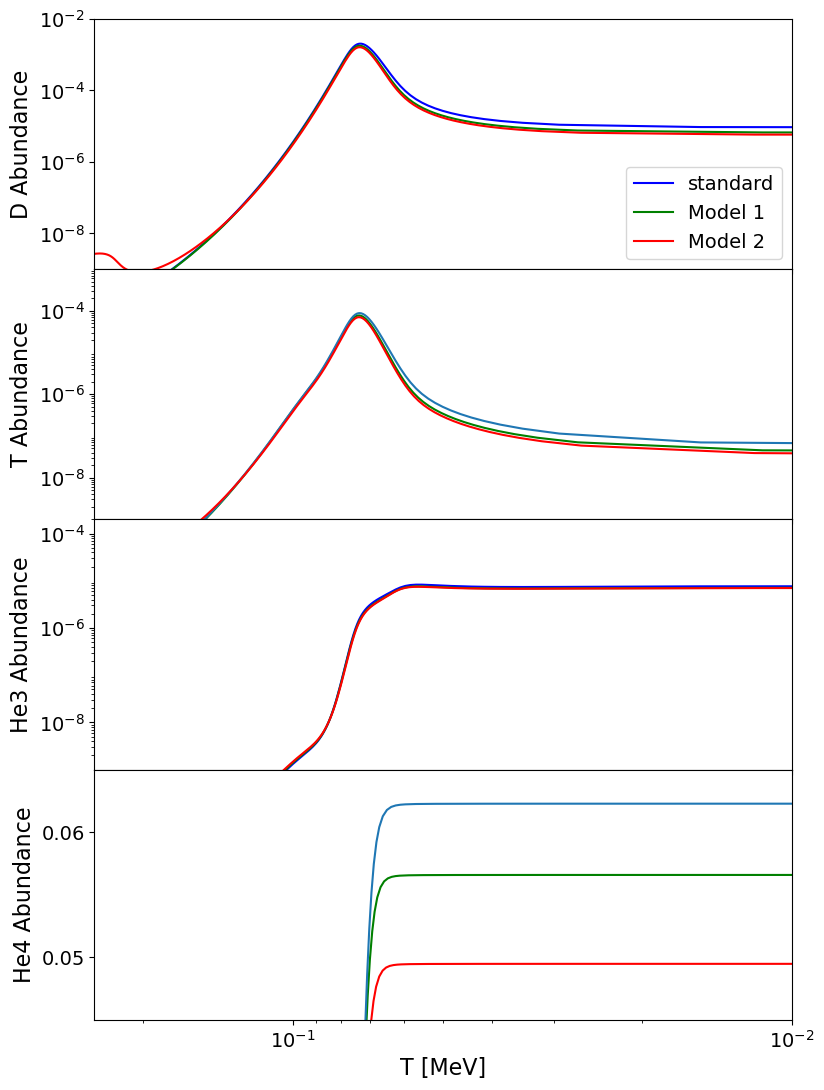

In [24]:
fig, ax = plt.subplots(4, 1, figsize=(9,13), sharex='col')
fig.subplots_adjust(hspace=0)

ax[0].loglog(y_total[:,0], y_total[:,3+nse.H2_INDEX],color = "blue", label="standard")
ax[0].loglog(y_total_Q3[:,0], y_total_Q3[:,3+nse.H2_INDEX], color = "green", label="Model 1")
ax[0].loglog(y_total_Q6[:,0], y_total_Q6[:,3+nse.H2_INDEX], color = "red", label="Model 2")
ax[0].set_xlim(0.25, 0.01)
ax[0].set_ylabel("D Abundance", fontsize=16)
ax[0].set_yticks([1e-8, 1e-6, 1e-4, 1e-2])
ax[0].tick_params(axis='y', labelsize=14)
ax[0].set_ylim(1e-9,1e-2)
ax[0].legend(loc = "lower right", fontsize=14)

ax[1].loglog(y_total_Q3[:,0], y_total_Q3[:,3+nse.H3_INDEX], color = "green")
ax[1].loglog(y_total[:,0], y_total[:,3+nse.H3_INDEX],)
ax[1].loglog(y_total_Q6[:,0], y_total_Q6[:,3+nse.H3_INDEX], color = "red")
ax[1].set_ylabel("T Abundance", fontsize=16)
ax[1].set_yticks([1e-8, 1e-6, 1e-4])
ax[1].set_ylim(1e-9,1e-3)
ax[1].tick_params(axis='y', labelsize=14)

ax[2].loglog(y_total[:,0], y_total[:,3+nse.HE3_INDEX],color="blue")
ax[2].loglog(y_total_Q3[:,0], y_total_Q3[:,3+nse.HE3_INDEX], color = "green")
ax[2].loglog(y_total_Q6[:,0], y_total_Q6[:,3+nse.HE3_INDEX], color = "red")
ax[2].set_ylabel("He3 Abundance", fontsize=16)
ax[2].set_yticks([1e-8, 1e-6, 1e-4])
ax[2].set_ylim(1e-9,2e-4)
ax[2].tick_params(axis='y', labelsize=14)

ax[3].semilogx(y_total_Q3[:,0], y_total_Q3[:,3+nse.HE4_INDEX], color = "green")
ax[3].semilogx(y_total[:,0], y_total[:,3+nse.HE4_INDEX],)
ax[3].semilogx(y_total_Q6[:,0], y_total_Q6[:,3+nse.HE4_INDEX], color = "red")
ax[3].set_ylabel("He4 Abundance", fontsize=16)
ax[3].set_yticks([0.05, 0.06, 0.07])
ax[3].set_ylim(0.045, 0.065)
ax[3].tick_params(axis='both', labelsize=14)
ax[3].set_xlabel("T [MeV]", fontsize=16)

plt.savefig("QBBN.png", bbox_inches="tight")

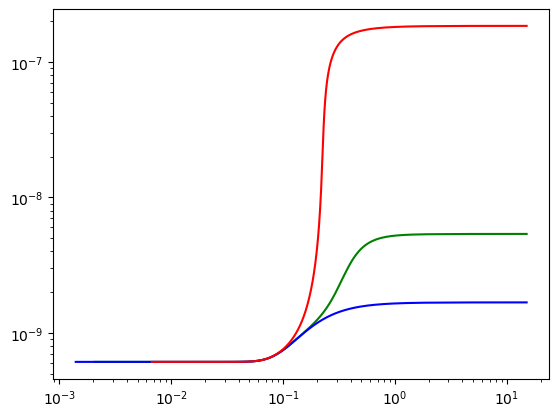

In [25]:
plt.loglog(y_total_Q3[:,0], y_total_Q3[:,2], color="green")
plt.loglog(y_total[:,0], y_total[:,2], color="blue")
plt.loglog(y_total_Q6[:,0], y_total_Q6[:,2], color="red")


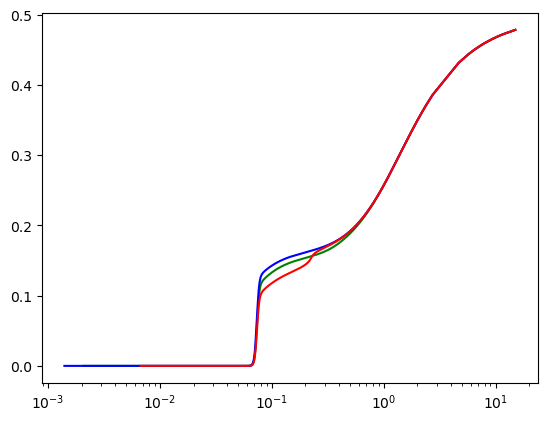

In [26]:
plt.semilogx(y_total_Q3[:,0], y_total_Q3[:,3+nse.N_INDEX], c="green")
plt.semilogx(y_total[:,0], y_total[:,3+nse.N_INDEX], c="blue")
plt.semilogx(y_total_Q6[:,0], y_total_Q6[:,3+nse.N_INDEX], c="red")


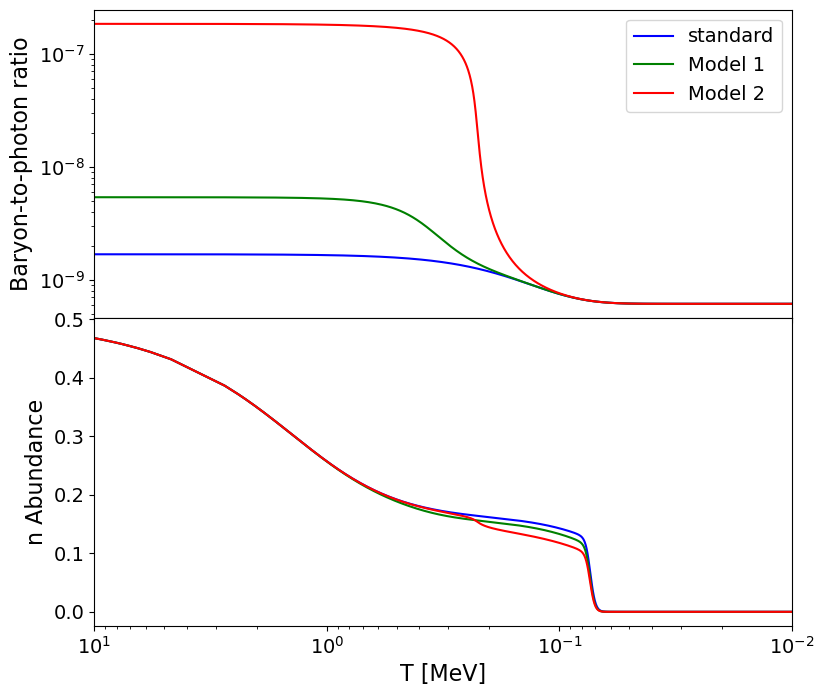

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(9,8), sharex='col')
fig.subplots_adjust(hspace=0)
ax[0].loglog(y_total[:,0], y_total[:,2], color="blue", label="standard")
ax[0].loglog(y_total_Q3[:,0], y_total_Q3[:,2], color="green", label="Model 1")
ax[0].loglog(y_total_Q6[:,0], y_total_Q6[:,2], color="red", label="Model 2")
ax[0].set_ylabel("Baryon-to-photon ratio", fontsize=16)
ax[0].tick_params(axis='y', labelsize=14)
ax[0].set_xlim(10, 1e-2)
ax[0].legend(loc = "upper right", fontsize=14)


ax[1].semilogx(y_total[:,0], y_total[:,3+nse.N_INDEX], c="blue")
ax[1].semilogx(y_total_Q3[:,0], y_total_Q3[:,3+nse.N_INDEX], c="green")
ax[1].semilogx(y_total_Q6[:,0], y_total_Q6[:,3+nse.N_INDEX], c="red")
ax[1].set_ylabel("n Abundance", fontsize=16)
ax[1].tick_params(axis='both', labelsize=14)
ax[1].set_xlabel("T [MeV]", fontsize=16)

plt.savefig("Qmodel.png", bbox_inches='tight')